Libraries Imported Successfully

Dataset Loaded Successfully
   user_id  year       country    age_group  gender   platform  anxiety_score  \
0    23655  2014  Saudi Arabia        Adult  Female  X/Twitter          61.24   
1    15796  2011         Spain  Young Adult    Male  X/Twitter          67.80   
2      861  2035        Brazil       Senior   Other  Instagram          79.80   
3     5391  2034           USA  Young Adult    Male     Reddit          49.41   
4    21576  2059        Mexico  Young Adult   Other     Twitch          84.60   

   depression_score  stress_level  loneliness_index  therapy_access  \
0             33.50         66.03             66.49            True   
1             47.65         72.91             48.61           False   
2             88.73         68.16             49.53           False   
3             48.83         51.07             66.71            True   
4             70.59         50.64             51.14            True   

   medication_usage  self

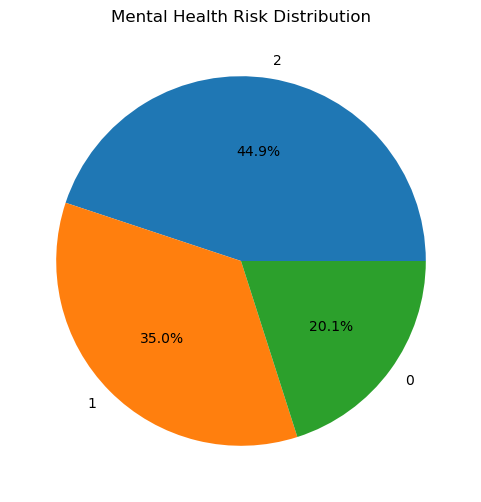


Feature Importance:
              Feature  Importance
12  self_esteem_score    0.112979
6       anxiety_score    0.112728
8        stress_level    0.112681
9    loneliness_index    0.112673
0             user_id    0.112183
7    depression_score    0.111771
1                year    0.090805
2             country    0.075846
5            platform    0.056782
3           age_group    0.040335
4              gender    0.027885
10     therapy_access    0.018086
11   medication_usage    0.015248


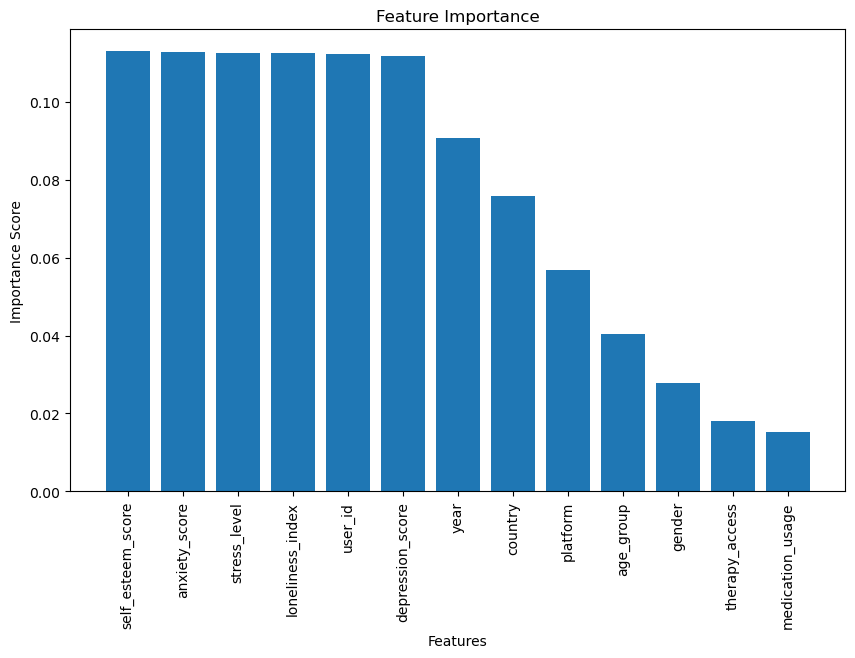

File saved successfully


In [2]:
# ============================================
# MENTAL HEALTH RISK PREDICTION PROJECT
# ============================================

# STEP 1 : IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries Imported Successfully")


# STEP 2 : LOAD DATASET
# ============================================

df = pd.read_csv(r"C:\Users\Admin\Downloads\OBSIP\Triveni_Task4\Dataset\mental_health_trends.csv")

print("\nDataset Loaded Successfully")

print(df.head())


# STEP 3 : DATASET INFORMATION
# ============================================

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


# STEP 4 : ENCODE CATEGORICAL COLUMNS
# ============================================

le = LabelEncoder()

categorical_columns = [
    'country',
    'age_group',
    'gender',
    'platform',
    'therapy_access',
    'medication_usage',
    'mental_health_risk'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("\nCategorical Data Encoded Successfully")


# STEP 5 : DEFINE FEATURES AND TARGET
# ============================================

X = df.drop('mental_health_risk', axis=1)

y = df['mental_health_risk']

print("\nFeatures and Target Selected")

print("X Shape :", X.shape)
print("Y Shape :", y.shape)


# STEP 6 : SPLIT TRAINING AND TESTING DATA
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nData Split Successfully")

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)


# STEP 7 : TRAIN MACHINE LEARNING MODEL
# ============================================

model = RandomForestClassifier()

model.fit(X_train, y_train)

print("\nModel Training Completed")


# STEP 8 : PREDICTION
# ============================================

y_pred = model.predict(X_test)

print("\nPrediction Completed")


# STEP 9 : MODEL EVALUATION
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# STEP 10 : DATA VISUALIZATION
# ============================================

risk_counts = df['mental_health_risk'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%'
)

plt.title("Mental Health Risk Distribution")

plt.show()


# STEP 11 : FEATURE IMPORTANCE
# ============================================

importance = model.feature_importances_

feature_names = X.columns

feature_data = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_data = feature_data.sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_data)


# STEP 12 : BAR CHART
# ============================================

plt.figure(figsize=(10,6))

plt.bar(feature_data['Feature'], feature_data['Importance'])

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.show()

# Save output file
df.to_csv("mental_health_output.csv", index=False)

print("File saved successfully")


# ============================================
# END OF PROJECT
# ============================================